In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load cleaned dataset

df = pd.read_csv("../processed/cleaned_youtube_data.csv")

df.head()

,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,traffic_source,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours,content_category
0,45.55,2422,88.62,564,Shorts Feed,28.70,1975899,88186,1055,63,1329340.94,Sports
1,59.12,562,15.84,523,Notifications,25.67,1552915,69884,5883,131,242427.29,Vlog
2,40.06,2369,98.56,628,External,10.13,90886,37931,3746,2555,59808.04,News
3,42.54,2097,82.16,239,External,25.00,999294,38861,1575,900,582088.76,Education
4,31.40,1424,75.58,138,Shorts Feed,23.49,1656171,57043,3150,1452,655107.64,Sports


In [3]:
X = df[["video_duration_min"]]

y = df["avg_view_percentage"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (29999, 1)
Target Shape : (29999,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 23999
Testing Samples : 6000


In [5]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

print("Original Shape :", X_train.shape)
print("Polynomial Shape :", X_train_poly.shape)

Original Shape : (23999, 1)
Polynomial Shape : (23999, 4)


In [6]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

print("Polynomial Regression model trained successfully.")

Polynomial Regression model trained successfully.


In [7]:
print("Intercept :", model.intercept_)

print("\nCoefficients:")

for feature, coef in zip(poly.get_feature_names_out(), model.coef_):
    print(feature, ":", coef)

Intercept : 52.01965914758641

Coefficients:
1 : 0.0
video_duration_min : -0.2565463032311252
video_duration_min^2 : 0.009075498558105828
video_duration_min^3 : -9.063240816027391e-05


In [8]:
y_pred = model.predict(X_test_poly)

y_pred[:10]

array([50.60116457, 50.59113227, 50.17695153, 50.88967994, 50.65903106,
       51.09554169, 50.51208242, 50.36527147, 49.97722849, 50.52143552])

In [9]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 24.945376459655154
Mean Squared Error : 828.8234203174394
Root Mean Squared Error : 28.789293501533507
R² Score : -0.00043050520898613165


/Users/kct/Desktop/Youtube_Analytics_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


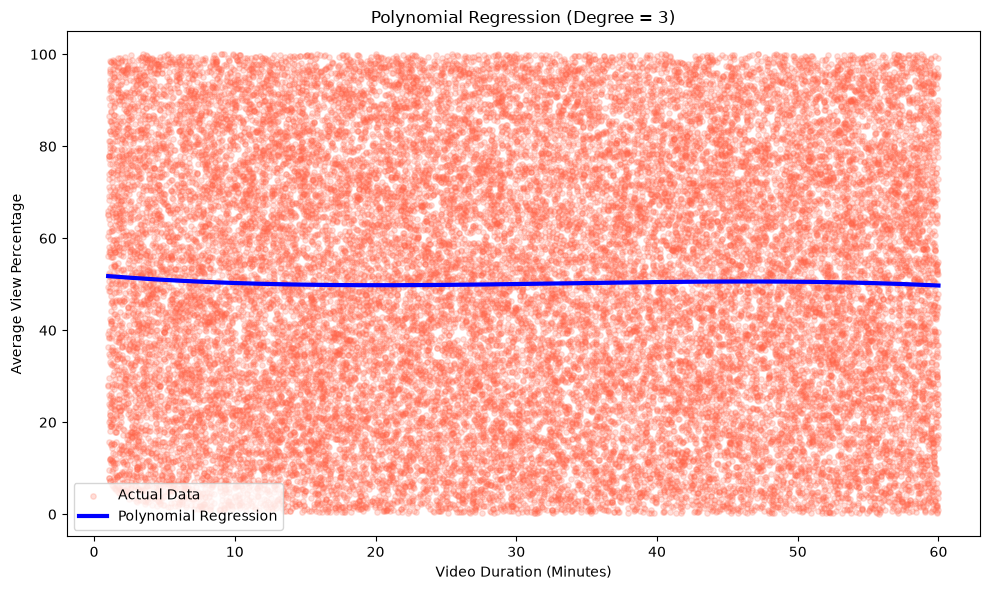

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y,
    color="tomato",
    alpha=0.20,
    s=15,
    label="Actual Data"
)

X_grid = np.linspace(
    X.min().values[0],
    X.max().values[0],
    500
).reshape(-1,1)

X_grid_poly = poly.transform(X_grid)

y_grid = model.predict(X_grid_poly)

plt.plot(
    X_grid,
    y_grid,
    color="blue",
    linewidth=3,
    label="Polynomial Regression"
)

plt.xlabel("Video Duration (Minutes)")
plt.ylabel("Average View Percentage")

plt.title("Polynomial Regression (Degree = 3)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/polynomial_regression_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

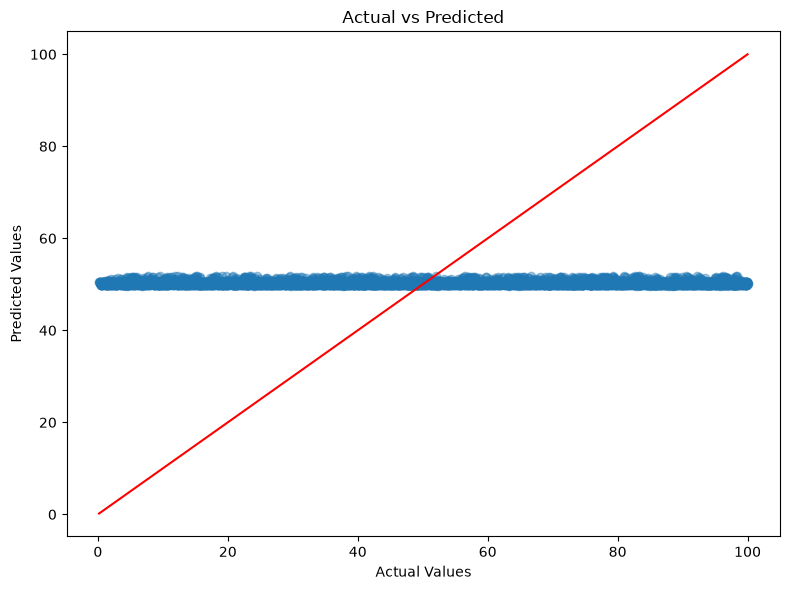

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

min_val = min(y_test.min(), y_pred.min())

max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red"
)

plt.tight_layout()

plt.savefig(
    "../images/polynomial_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    {
        "model": model,
        "poly": poly
    },
    "../models/polynomial_regression.pkl"
)

print("Polynomial model saved successfully.")

Polynomial model saved successfully.
